In [1]:
from pathlib import Path

ROOT = Path.cwd()

for folder in ["data", "models", "plots"]:
    (ROOT / folder).mkdir(parents=True, exist_ok=True)

print(ROOT)

/home/shubham/Documents/projects/iitisoc-hmm-market-regimes/notebooks


In [2]:
%pip install yfinance scikit-learn hmmlearn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import joblib

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from pathlib import Path

import matplotlib.pyplot as plt

In [4]:

data = yf.download(
    "^NSEI",
    start= "2010-01-01",
    end= "2026-01-01",
    auto_adjust=True
)
print(data.head())
# print(data.columns)
print(data.shape)

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open Volume
Ticker            ^NSEI        ^NSEI        ^NSEI        ^NSEI  ^NSEI
Date                                                                 
2010-01-04  5232.200195  5238.450195  5167.100098  5200.899902      0
2010-01-05  5277.899902  5288.350098  5242.399902  5277.149902      0
2010-01-06  5281.799805  5310.850098  5260.049805  5278.149902      0
2010-01-07  5263.100098  5302.549805  5244.750000  5281.799805      0
2010-01-08  5244.750000  5276.750000  5234.700195  5264.250000      0
(3929, 5)


In [5]:
# Flatten MultiIndex columns
data.columns = data.columns.get_level_values(0)
# Convert Date index to normal column
data = data.reset_index()
# Remove column index name
data.columns.name = None
# Sort by date
data = data.sort_values("Date").reset_index(drop=True)
# Save clean dataset
data.to_csv(
    ROOT / "data" / "clean_data.csv"
)
print(data.columns)
print(data.shape)

data.head()

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
(3929, 6)


,Date,Close,High,Low,Open,Volume
0,2010-01-04,5232.200195,5238.450195,5167.100098,5200.899902,0
1,2010-01-05,5277.899902,5288.350098,5242.399902,5277.149902,0
2,2010-01-06,5281.799805,5310.850098,5260.049805,5278.149902,0
3,2010-01-07,5263.100098,5302.549805,5244.750000,5281.799805,0
4,2010-01-08,5244.750000,5276.750000,5234.700195,5264.250000,0


In [6]:

# Calculate log returns
data["Log_Return"] = np.log(
    data["Close"] / data["Close"].shift(1)
)
# garman-klass volatility
data["gk_volatility"] = np.sqrt(0.5*(np.log(data["High"]/data["Low"]))**2
    -(2*np.log(2)-1) * (np.log(data["Close"]/data["Open"]))**2)
# Range Feature
data["Range"] = (
    data["High"] - data["Low"]
) / data["Close"]
# Remove NaN values created by rolling window
data = data.dropna().reset_index(drop=True)


In [7]:
features = data[[
    "Date",
    "Log_Return",
    "gk_volatility",
    "Range"
]].copy()
print(features.head())
print(features.shape)

        Date  Log_Return  gk_volatility     Range
0 2010-01-05    0.008696       0.006170  0.008706
1 2010-01-06    0.000739       0.006783  0.009618
2 2010-01-07   -0.003547       0.007430  0.010982
3 2010-01-08   -0.003493       0.005166  0.008018
4 2010-01-11    0.000886       0.007806  0.011316
(3928, 4)


In [8]:
# Chronological Train-Test Split (80% Train, 20% Test)

split_index = int(len(features) * 0.8)

train_features = features.iloc[:split_index].copy()
test_features = features.iloc[split_index:].copy()

print("Training samples:", len(train_features))
print("Testing samples :", len(test_features))

Training samples: 3142
Testing samples : 786


In [9]:

X_train = train_features[["Log_Return", "gk_volatility","Range"]]
X_test = test_features[["Log_Return", "gk_volatility","Range"]]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
# print(X_scaled[:5])
# print(X_scaled.shape)


In [10]:

hmm_model = GaussianHMM(
    n_components=4,
    covariance_type="full",
    n_iter=100,
    random_state=42
)

hmm_model.fit(X_train_scaled)

train_log_likelihood = hmm_model.score(X_train_scaled)

test_log_likelihood = hmm_model.score(X_test_scaled)

print("Training completed")

print("Train Log Likelihood:", train_log_likelihood)

print("Test Log Likelihood:", test_log_likelihood)
print("Number of states:", hmm_model.n_components)



Training completed
Train Log Likelihood: -5075.664262883404
Test Log Likelihood: -1579.38680572247
Number of states: 4


In [11]:


joblib.dump(
    hmm_model,
    "hmm_model.pkl"
)

['hmm_model.pkl']

In [12]:
print("State Means:")
print(hmm_model.means_)
print("\nTransition Matrix:")
print(hmm_model.transmat_)


State Means:
[[ 0.10712094 -0.31867045 -0.47294159]
 [-0.17051606  0.63995827  0.76224827]
 [ 0.05251708 -0.36561609 -0.30842208]
 [-0.68245814  3.96060237  4.27302636]]

Transition Matrix:
[[4.24931795e-01 1.44638489e-01 4.21979616e-01 8.45010013e-03]
 [2.69303328e-01 5.88167626e-01 1.16405298e-01 2.61237478e-02]
 [4.21898832e-01 1.29539417e-01 4.45816061e-01 2.74568944e-03]
 [8.87047801e-23 5.87430553e-01 1.75974480e-03 4.10809702e-01]]


In [13]:
features.to_csv(
    ROOT / "data" / "features.csv",
    index=False
)

print("features.csv saved")

features.csv saved


In [14]:
train_states = hmm_model.predict(X_train_scaled)

test_states = hmm_model.predict(X_test_scaled)

train_features["State"] = train_states

test_features["State"] = test_states
train_features["State"] = train_states
test_features["State"] = test_states

features = pd.concat(
    [train_features, test_features],
    ignore_index=True
)
print("\nState Counts:")
print(features["State"].value_counts())

print("\nState Statistics:")
print(
    features.groupby("State")[
        ["Log_Return", "gk_volatility", "Range"]
    ].mean()
)

states_df = features[
    ["Date", "State"]
].copy()


State Counts:
State
0    1530
2    1295
1    1039
3      64
Name: count, dtype: int64

State Statistics:
       Log_Return  gk_volatility     Range
State                                     
0        0.001570       0.005580  0.008152
1       -0.001502       0.010123  0.017877
2        0.000869       0.005332  0.009470
3       -0.005611       0.026797  0.047189


In [15]:
states_df.to_csv(
    ROOT /"data" / "states.csv",
    index=False
)
print("states.csv saved successfully")

states.csv saved successfully


In [16]:
train_probs = hmm_model.predict_proba(X_train_scaled)

test_probs = hmm_model.predict_proba(X_test_scaled)

state_probs = np.vstack(
    [train_probs, test_probs]
)
prob_df = pd.DataFrame(
    state_probs,
    columns=[
        f"State_{i}"
        for i in range(
            hmm_model.n_components
        )
    ]
)
prob_df["Date"] = features["Date"]
prob_df.to_csv(
    ROOT / "data" / "state_probabilities.csv",
    index=False
)
print("state_probabilities.csv saved")

state_probabilities.csv saved


In [17]:
train_features.to_csv(
    ROOT/"data"/"train_data.csv",
    index=False
)

test_features.to_csv(
    ROOT/"data"/"test_data.csv",
    index=False
)

In [18]:
transition_df = pd.DataFrame(
    hmm_model.transmat_
)

transition_df.to_csv(
    ROOT / "data" / "transition_matrix.csv",
    index=False
)
print("transition_matrix.csv saved")

transition_matrix.csv saved


In [19]:
import numpy as np

stats = []

# features["GK_Volatility"] = np.sqrt(
#     0.5 * (np.log(features["High"] / features["Low"])) ** 2
#     - (2 * np.log(2) - 1)
#     * (np.log(features["Close"] / features["Open"])) ** 2
# )

for state in range(
    hmm_model.n_components
):

    state_data = features[
        features["State"] == state
    ]

    mean_return = (
        state_data["Log_Return"]
        .mean()
    )

    gk_volatility = state_data["gk_volatility"].mean()

    sharpe = (
        mean_return /
        gk_volatility
        if gk_volatility > 0
        else np.nan
    )

    downside = state_data[
        state_data["Log_Return"] < 0
    ]["Log_Return"]

    sortino = (
        mean_return /
        downside.std()
        if len(downside) > 1
        else np.nan
    )

    stats.append({
        "State": state,
        "Frequency": len(state_data),
        "Mean_Return": mean_return,
        "gk_Volatility": gk_volatility,
        "Sharpe_Ratio": sharpe,
        "Sortino_Ratio": sortino
    })

state_characteristics = pd.DataFrame(
    stats
)
state_characteristics.to_csv(
    ROOT / "data" / "state_characteristics.csv",
    index=False
)
state_characteristics

,State,Frequency,Mean_Return,gk_Volatility,Sharpe_Ratio,Sortino_Ratio
0,0,1530,0.001570,0.005580,0.281382,0.843127
1,1,1039,-0.001502,0.010123,-0.148351,-0.211814
2,2,1295,0.000869,0.005332,0.162959,0.229844
3,3,64,-0.005611,0.026797,-0.209376,-0.199808


In [20]:
persistence = []

for i in range(
    hmm_model.n_components
):

    pii = hmm_model.transmat_[i, i]

    persistence.append({
        "State": i,
        "Persistence": pii,
        "Expected_Duration":
            1/(1-pii)
    })

persistence_df = pd.DataFrame(
    persistence
)

persistence_df.to_csv(
    ROOT / "data" / "persistence_metrics.csv",
    index=False
)
persistence_df

,State,Persistence,Expected_Duration
0,0,0.424932,1.738924
1,1,0.588168,2.428172
2,2,0.445816,1.804455
3,3,0.410810,1.697245


In [21]:
import joblib
joblib.dump(
    hmm_model,
    "hmm_model.pkl"
)
joblib.dump(
    scaler,
    "scaler.pkl"
)
print("Model and scaler saved")

Model and scaler saved


,Date,Close,High,Low,Open,Volume,Log_Return,gk_volatility,Range,State
0,2010-01-05,5277.899902,5288.350098,5242.399902,5277.149902,0,0.008696,0.006170,0.008706,0
1,2010-01-06,5281.799805,5310.850098,5260.049805,5278.149902,0,0.000739,0.006783,0.009618,0
2,2010-01-07,5263.100098,5302.549805,5244.750000,5281.799805,0,-0.003547,0.007430,0.010982,0
3,2010-01-08,5244.750000,5276.750000,5234.700195,5264.250000,0,-0.003493,0.005166,0.008018,0
4,2010-01-11,5249.399902,5287.200195,5227.799805,5263.799805,0,0.000886,0.007806,0.011316,0


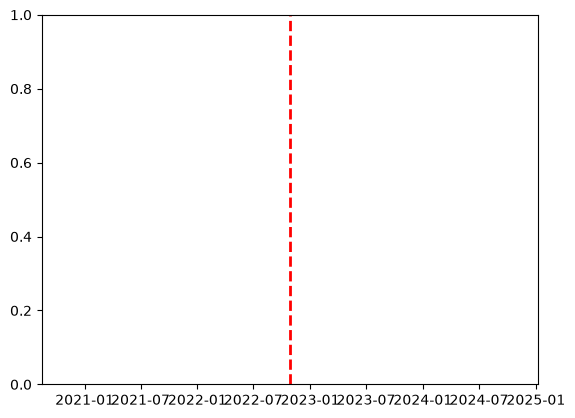

In [22]:
plot_data = data.copy()

# Keep only rows corresponding to the engineered features
plot_data = plot_data.iloc[-len(features):].copy()

# Add predicted states from the combined dataframe
plot_data["State"] = features["State"].values

# Mark the train/test split
split_date = test_features["Date"].iloc[0]

plt.axvline(
    split_date,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Train/Test Split"
)

plot_data.head()

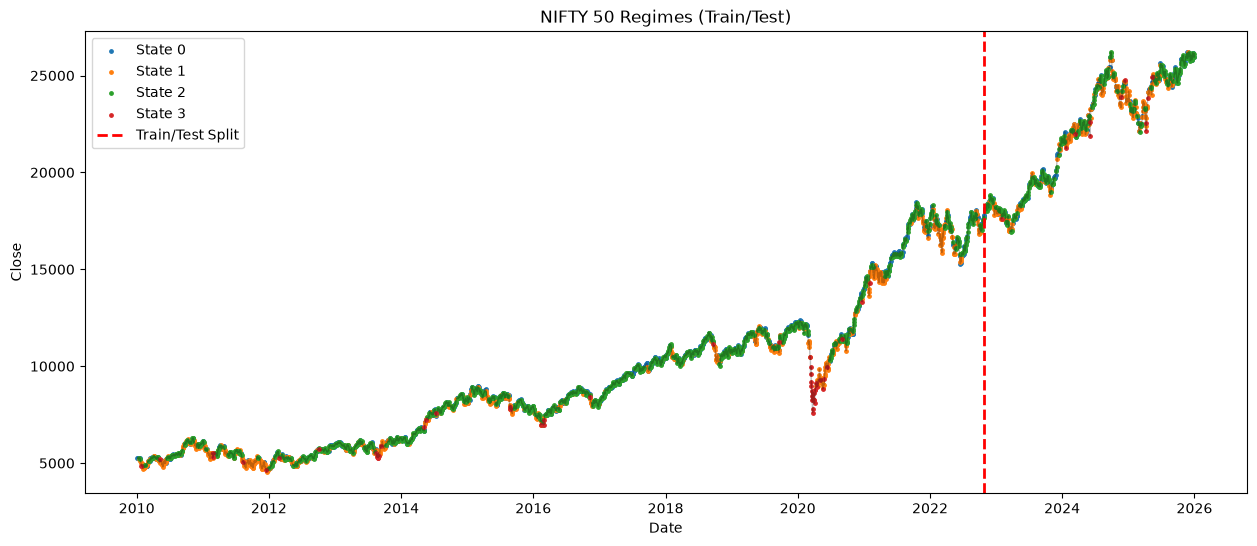

In [23]:
plt.figure(figsize=(15, 6))

for state in sorted(plot_data["State"].unique()):
    mask = plot_data["State"] == state

    plt.scatter(
        plot_data.loc[mask, "Date"],
        plot_data.loc[mask, "Close"],
        s=6,
        label=f"State {state}"
    )

# Price line
plt.plot(
    plot_data["Date"],
    plot_data["Close"],
    color="black",
    alpha=0.25,
    linewidth=1
)

# Train/Test split
plt.axvline(
    split_date,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Train/Test Split"
)

plt.title("NIFTY 50 Regimes (Train/Test)")
plt.xlabel("Date")
plt.ylabel("Close")
plt.legend()

plt.savefig(
    ROOT / "plots" / "market_regimes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [24]:
import os

print(os.getcwd())
print(os.listdir())

/home/shubham/Documents/projects/iitisoc-hmm-market-regimes/notebooks
['.gitkeep', 'tempCodeRunnerFile.ipynb', 'best_state.ipynb', 'backtesting_analysis.ipynb', 'scaler.pkl', 'base_hmm_model.ipynb', 'data', 'models', 'plots', 'hmm_model.pkl']


In [1]:
import numpy as np
import pandas as pd

print("="*100)
print("MODEL SUMMARY")
print("="*100)

print(f"Hidden States        : {hmm_model.n_components}")
print(f"Observations         : {len(features):,}")

# ------------------------------------------------------------------
# Log Likelihood
# ------------------------------------------------------------------

if "X_train_scaled" in globals():
    train_ll = hmm_model.score(X_train_scaled)
    test_ll = hmm_model.score(X_test_scaled)

    print(f"\nTrain Log-Likelihood : {train_ll:.2f}")
    print(f"Test Log-Likelihood  : {test_ll:.2f}")

    print(f"Train Avg LL         : {train_ll/len(X_train_scaled):.4f}")
    print(f"Test Avg LL          : {test_ll/len(X_test_scaled):.4f}")

else:
    ll = hmm_model.score(X_scaled)
    print(f"\nOverall Log-Likelihood : {ll:.2f}")
    print(f"Average Log-Likelihood : {ll/len(X_scaled):.4f}")

# ------------------------------------------------------------------
# State Counts
# ------------------------------------------------------------------

print("\n" + "="*100)
print("STATE COUNTS")
print("="*100)

if "train_states" in globals():

    print("\nTRAIN")
    print(pd.Series(train_states).value_counts().sort_index())

    print("\nTEST")
    print(pd.Series(test_states).value_counts().sort_index())

else:

    print(pd.Series(states).value_counts().sort_index())

# ------------------------------------------------------------------
# State Characteristics
# ------------------------------------------------------------------

print("\n" + "="*100)
print("STATE CHARACTERISTICS")
print("="*100)

analysis = features.copy()

if "states" in globals():
    analysis["State"] = states

summary = (
    analysis.groupby("State")
    .agg(
        Count=("State","size"),
        Mean_Return=("Log_Return","mean"),
        Return_STD=("Log_Return","std"),
        Mean_GK_Vol=("gk_volatility","mean"),
        Mean_Range=("Range","mean"),
    )
    .round(6)
)

print(summary)

# ------------------------------------------------------------------
# Transition Matrix
# ------------------------------------------------------------------

print("\n" + "="*100)
print("TRANSITION MATRIX")
print("="*100)

transition = pd.DataFrame(
    hmm_model.transmat_,
    index=[f"S{i}" for i in range(hmm_model.n_components)],
    columns=[f"S{i}" for i in range(hmm_model.n_components)]
)

print(transition.round(3))

# ------------------------------------------------------------------
# Persistence
# ------------------------------------------------------------------

print("\n" + "="*100)
print("EXPECTED DURATION")
print("="*100)

expected_duration = 1 / (1 - np.diag(hmm_model.transmat_))

persistence = pd.DataFrame({
    "State": range(hmm_model.n_components),
    "Persistence": np.diag(hmm_model.transmat_),
    "Expected_Duration": expected_duration
})

print(persistence.round(3))

print("\n" + "="*100)
print("END OF MODEL SUMMARY")
print("="*100)

MODEL SUMMARY


NameError: name 'hmm_model' is not defined

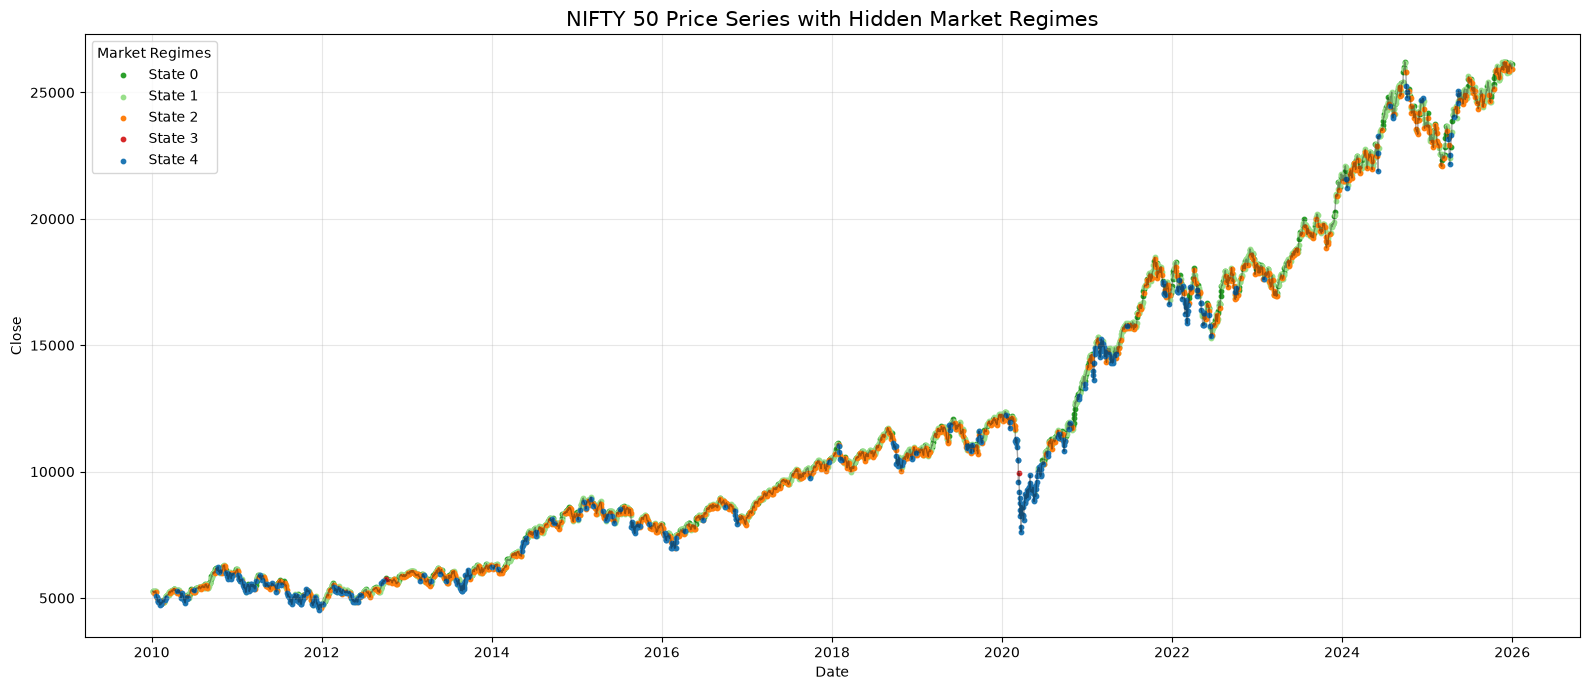